# **Predicting Waze User Churn**
**Stage 2 - Exploratory Data Analysis**

**Situation:** We're still in the early stages of user churn project. So far, we've completed a project proposal and used Python to inspect and organize Waze's user data.

The current stage shows exploratory data analysis (EDA) and further data visualization.

# **Course 2 End-of-course project: Exploratory data analysis**

In this stage, we will examine data provided and prepare it for analysis.
<br/>

**The purpose** of this project is to conduct exploratory data analysis (EDA) on a provided dataset.

**The goal** is to continue the examination of the data that we began in the previous stage, adding relevant visualizations that help communicate the story that the data tells.
<br/>


*This stage has 4 parts:*

**Part 1:** Imports, links, and loading

**Part 2:** Data Exploration
*   Data cleaning


**Part 3:** Building visualizations

**Part 4:** Evaluating and sharing results


# **Visualize a story in Python**

# **PACE stages**


Throughout this stage notebook, we'll use references to the problem-solving framework PACE. The following notebook components are labeled with the respective PACE stage: Plan, Analyze, Construct, and Execute.

## **PACE: Plan**

### **Part 1. Imports and data loading**

For EDA of the data, importing the data and packages that will be most helpful, such as pandas, numpy, and matplotlib.




In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Loading the dataset into a dataframe
df = pd.read_csv('waze_dataset.csv')


## **PACE: Analyze**


1. Data don't need any further restructuring or converting.
2. `label` column has many missing data (700 value).

### **Part 2. Data exploration and cleaning**

1. Most important columns are `label, drives, driven_km_drives, activity_days, driving_days`, given the scenario. <br>
2. `Device` column can be eliminated, since it won't help solving our problem.
3. Checking for missing data can be done using `info()` method. Missing data in label column can be handled by dropping them since they are not indicating any useful information.
4. Outliers can be checked using comparsion between `mean` and `median` or by plotting a `box plot` or `histogram`. They can be handled by eliminating, reasigning or keeping them based on the specific goals and next processes of the dataset.

#### **Data overview and summary statistics**

We'll use the following methods and attributes on the dataframe:

* `head()`
* `size`
* `describe()`
* `info()`

It's always helpful to have this information at the beginning of a project, where we can always refer back to if needed.

In [ ]:
df.head()

,ID,label,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days,device
0,0,retained,283,226,296.748273,2276,208,0,2628.845068,1985.775061,28,19,Android
1,1,retained,133,107,326.896596,1225,19,64,13715.920550,3160.472914,13,11,iPhone
2,2,retained,114,95,135.522926,2651,0,0,3059.148818,1610.735904,14,8,Android
3,3,retained,49,40,67.589221,15,322,7,913.591123,587.196542,7,3,iPhone
4,4,retained,84,68,168.247020,1562,166,5,3950.202008,1219.555924,27,18,Android


In [ ]:
df.size

194987

Generating summary statistics using the `describe()` method.

In [ ]:
df.describe()

,ID,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,7499.000000,80.633776,67.281152,189.964447,1749.837789,121.605974,29.672512,4039.340921,1860.976012,15.537102,12.179879
std,4329.982679,80.699065,65.913872,136.405128,1008.513876,148.121544,45.394651,2502.149334,1446.702288,9.004655,7.824036
min,0.000000,0.000000,0.000000,0.220211,4.000000,0.000000,0.000000,60.441250,18.282082,0.000000,0.000000
25%,3749.500000,23.000000,20.000000,90.661156,878.000000,9.000000,0.000000,2212.600607,835.996260,8.000000,5.000000
50%,7499.000000,56.000000,48.000000,159.568115,1741.000000,71.000000,9.000000,3493.858085,1478.249859,16.000000,12.000000
75%,11248.500000,112.000000,93.000000,254.192341,2623.500000,178.000000,43.000000,5289.861262,2464.362632,23.000000,19.000000
max,14998.000000,743.000000,596.000000,1216.154633,3500.000000,1236.000000,415.000000,21183.401890,15851.727160,31.000000,30.000000


And summary information using the `info()` method.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       14999 non-null  int64  
 1   label                    14299 non-null  object 
 2   sessions                 14999 non-null  int64  
 3   drives                   14999 non-null  int64  
 4   total_sessions           14999 non-null  float64
 5   n_days_after_onboarding  14999 non-null  int64  
 6   total_navigations_fav1   14999 non-null  int64  
 7   total_navigations_fav2   14999 non-null  int64  
 8   driven_km_drives         14999 non-null  float64
 9   duration_minutes_drives  14999 non-null  float64
 10  activity_days            14999 non-null  int64  
 11  driving_days             14999 non-null  int64  
 12  device                   14999 non-null  object 
dtypes: float64(3), int64(8), object(2)
memory usage: 1.5+ MB


## **PACE: Construct**

>
1. Outliers can be checked using comparsion between `mean` and `median` or by plotting a `box plot` or `histogram`.
2. They can be handled by eliminating if using sensetive ML model, reasigning them to average values or keeping them if the data is to be used for EDA only, based on the specific goals and next processes of the dataset.

### **Part 3a. Visualizations**

Let's select data visualization types that will help us understand and explain the data.

Now that we know which data columns we'll use, it is time to decide which data visualization makes the most sense for EDA of the Waze dataset:

* Bar chart
* Box plot
* Histogram
* Heat map
* Scatter plot


Let's begin by examining the spread and distribution of important variables using box plots and histograms.

#### **`sessions`**

_The number of occurrence of a user opening the app during the month_

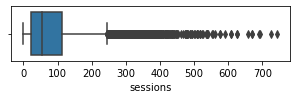

In [ ]:
# Box plot
plt.figure(figsize=(5,1))
sns.boxplot(x=df['sessions'])

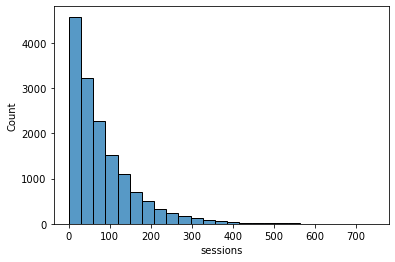

In [ ]:
# Histogram
sns.histplot(x=df['sessions'],bins=25)

The `sessions` variable is a right-skewed distribution with half of the observations having 56 or fewer sessions. However, as indicated by the boxplot, some users have more than 700.

#### **`drives`**

_An occurrence of driving at least 1 km during the month_

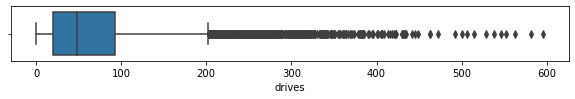

In [ ]:
# Box plot
plt.figure(figsize=(10,1))
sns.boxplot(x=df['drives'])

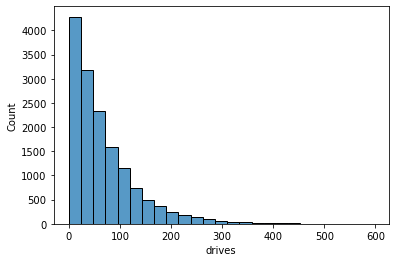

In [ ]:
# Histogram
sns.histplot(x=df['drives'], bins=25)

The `drives` information follows a distribution similar to the `sessions` variable. It is right-skewed, approximately log-normal, with a median of 48. However, some drivers had over 400 drives in the last month.

#### **`total_sessions`**

_A model estimate of the total number of sessions since a user has onboarded_

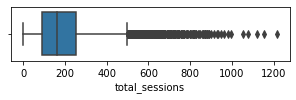

In [ ]:
# Box plot
plt.figure(figsize=(5,1))
sns.boxplot(x=df['total_sessions'])

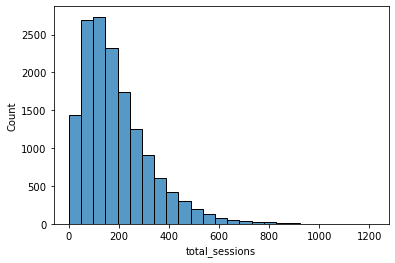

In [ ]:
# Histogram
sns.histplot(x=df['total_sessions'], bins=25)

The `total_sessions` is a right-skewed distribution. The median total number of sessions is 159.6. This is interesting information because, if the median number of sessions in the last month was 48 and the median total sessions was ~160, then it seems that a large proportion of a user's total drives might have taken place in the last month. This is something we can examine more closely later.

#### **`n_days_after_onboarding`**

_The number of days since a user signed up for the app_

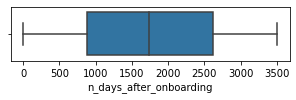

In [ ]:
# Box plot
plt.figure(figsize=(5,1))
sns.boxplot(x=df['n_days_after_onboarding'])

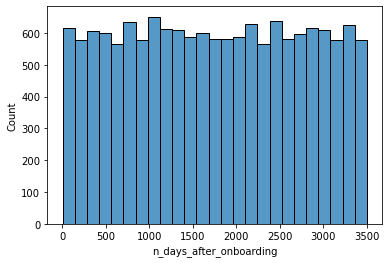

In [ ]:
# Histogram
sns.histplot(x=df['n_days_after_onboarding'], bins=25)

The total user tenure (i.e., number of days since
onboarding) is a uniform distribution with values ranging from near-zero to \~3,500 (\~9.5 years).

#### **`driven_km_drives`**

_Total kilometers driven during the month_

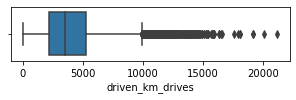

In [ ]:
# Box plot
plt.figure(figsize=(5,1))
sns.boxplot(x=df['driven_km_drives'])

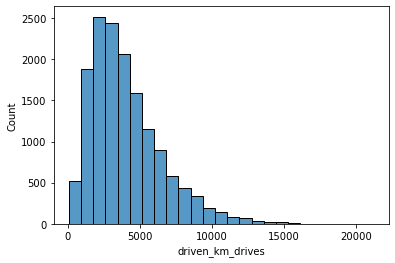

In [ ]:
# Histogram
sns.histplot(x=df['driven_km_drives'], bins=25)

The number of drives driven in the last month per user is a right-skewed distribution with half the users driving under 3,495 kilometers. As we discovered in the analysis from the previous stage, the users in this dataset drive _a lot_. The longest distance driven in the month was over half the circumferene of the earth.

#### **`duration_minutes_drives`**

_Total duration driven in minutes during the month_

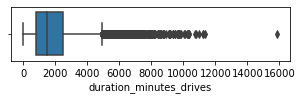

In [ ]:
# Box plot
plt.figure(figsize=(5,1))
sns.boxplot(x=df['duration_minutes_drives'])

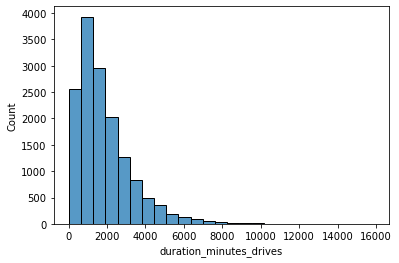

In [ ]:
# Histogram
sns.histplot(x=df['duration_minutes_drives'], bins=25)

The `duration_minutes_drives` variable has a heavily skewed right tail. Half of the users drove less than \~1,478 minutes (\~25 hours), but some users clocked over 250 hours over the month.

#### **`activity_days`**

_Number of days the user opens the app during the month_

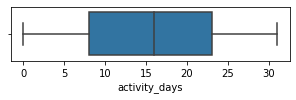

In [ ]:
# Box plot
plt.figure(figsize=(5,1))
sns.boxplot(x=df['activity_days'])

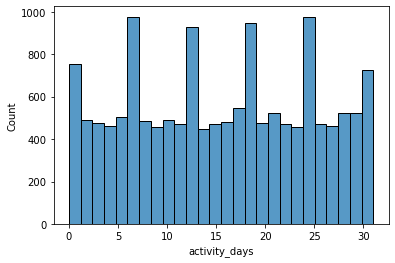

In [ ]:
# Histogram
sns.histplot(x=df['activity_days'])

Within the last month, users opened the app a median of 16 times. The box plot reveals a centered distribution. The histogram shows a nearly uniform distribution of ~500 people opening the app on each count of days. However, there are ~250 people who didn't open the app at all and ~250 people who opened the app every day of the month.

This distribution is noteworthy because it does not mirror the `sessions` distribution, which you might think would be closely correlated with `activity_days`.

#### **`driving_days`**

_Number of days the user drives (at least 1 km) during the month_

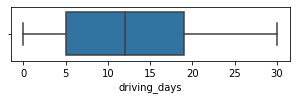

In [ ]:
# Box plot
plt.figure(figsize=(5,1))
sns.boxplot(x=df['driving_days'])

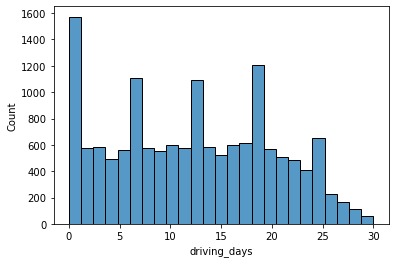

In [ ]:
# Histogram
sns.histplot(x=df['driving_days'], bins=25)

The number of days users drove each month is almost uniform, and it largely correlates with the number of days they opened the app that month, except the `driving_days` distribution tails off on the right.

However, there were almost twice as many users (\~1,000 vs. \~550) who did not drive at all during the month. This might seem counterintuitive when considered together with the information from `activity_days`. That variable had \~500 users opening the app on each of most of the day counts, but there were only \~250 users who did not open the app at all during the month and ~250 users who opened the app every day. Further investigation may be performed later.

#### **`device`**

_The type of device a user starts a session with_

This is a categorical variable, so we do not plot a box plot for it. A good plot for a binary categorical variable is a pie chart.

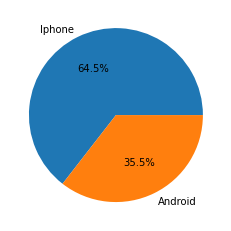

In [ ]:
# Pie chart
plt.pie(df['device'].value_counts(), labels=['Iphone','Android'],autopct='%1.1f%%');

There are nearly twice as many iPhone users as Android users represented in this data.

#### **`label`**

_Binary target variable (“retained” vs “churned”) for if a user has churned anytime during the course of the month_

This is also a categorical variable, and as such would not be plotted as a box plot. Plot a pie chart instead.

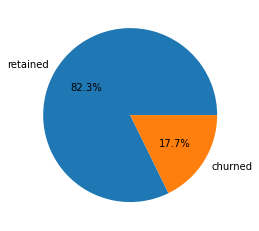

In [ ]:
# Pie chart
plt.pie(df['label'].value_counts(), labels=['retained','churned'],autopct='%1.1f%%');

Less than 18% of the users churned.

#### **`driving_days` vs. `activity_days`**

Because both `driving_days` and `activity_days` represent counts of days over a month and they're also closely related, we can plot them together on a single histogram. This will help to better understand how they relate to each other without having to scroll back and forth comparing histograms in two different places.

Plotting a histogram that, for each day, has a bar representing the counts of `driving_days` and `activity_days`.

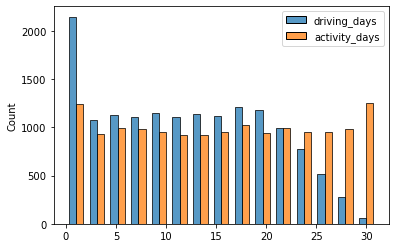

In [ ]:
# Histogram
sns.histplot(df[['driving_days','activity_days']], multiple='dodge', shrink=0.7, bins=15)

As observed previously, this might seem counterintuitive. After all, why are there _fewer_ people who didn't use the app at all during the month and _more_ people who didn't drive at all during the month?

On the other hand, it could just be illustrative of the fact that, while these variables are related to each other, they're not the same. People probably just open the app more than they use the app to drive&mdash;perhaps to check drive times or route information, to update settings, or even just by mistake.

Nonetheless, it might be worthwile to contact the data team at Waze to get more information about this, especially because it seems that the number of days in the month is not the same between variables.

Confirming the maximum number of days for each variable&mdash;`driving_days` and `activity_days`.

In [ ]:
print(df['driving_days'].max())
print(df['activity_days'].max())

30
31


It's true. Although it's possible that not a single user drove all 31 days of the month, it's highly unlikely, considering there are 15,000 people represented in the dataset.

One other way to check the validity of these variables is to plot a simple scatter plot with the x-axis representing one variable and the y-axis representing the other.

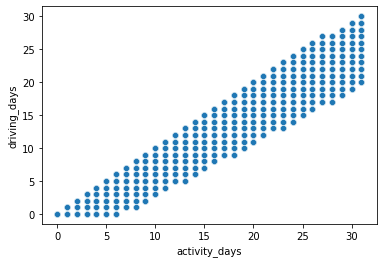

In [ ]:
# Scatter plot
sns.scatterplot(data=df,y='driving_days', x ='activity_days')

Notice that there is a theoretical limit. If we use the app to drive, then by definition it must count as a day-use as well. In other words, you cannot have more drive-days than activity-days. None of the samples in this data violate this rule, which is good.

#### **Retention by device**

Let's plot a histogram that has four bars&mdash;one for each device-label combination&mdash;to show how many iPhone users were retained/churned and how many Android users were retained/churned.

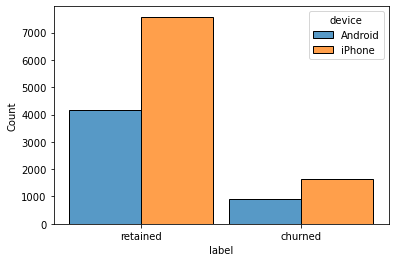

In [ ]:
# Histogram
sns.histplot(data=df,x='label',hue='device', multiple='dodge',shrink=0.9)

The proportion of churned users to retained users is consistent between device types.

#### **Retention by kilometers driven per driving day**

In the previous stage, we discovered that the median distance driven per driving day last month for users who churned was 697.54 km, versus 289.55 km for people who did not churn. Examine this further.

1. We'll create a new column in `df` called `km_per_driving_day`, which represents the mean distance driven per driving day for each user.

2. Then, we'll call the `describe()` method on the new column.

In [ ]:
# 1. Creating `km_per_driving_day` column
df['km_per_driving_day'] = df['driven_km_drives'] / df['driving_days']
# 2. Calling `describe()` on the new column
df['km_per_driving_day'].describe()

count    1.499900e+04
mean              inf
std               NaN
min      3.022063e+00
25%      1.672804e+02
50%      3.226746e+02
75%      7.370429e+02
max               inf
Name: km_per_driving_day, dtype: float64

The mean value is infinity, the standard deviation is NaN, and the max value is infinity.

This is the result of there being values of zero in the `driving_days` column. Pandas imputes a value of infinity in the corresponding rows of the new column because division by zero is undefined.

1. Let's convert these values from infinity to zero. You can use `np.inf` to refer to a value of infinity.

2. Then, Calling `describe()` on the `km_per_driving_day` column to verify that it worked.

In [ ]:
# 1. Converting infinite values to zero
df[df['km_per_driving_day']== np.inf] = 0
# 2. Confirming that it worked
df['km_per_driving_day'].describe()

count    14999.000000
mean       564.332421
std        963.973921
min          0.000000
25%        136.238895
50%        272.889272
75%        542.953671
max       8889.794236
Name: km_per_driving_day, dtype: float64

The maximum value is 15,420 kilometers _per drive day_. This is physically impossible. Driving 100 km/hour for 12 hours is 1,200 km. It's unlikely many people averaged more than this each day they drove, so, for now, disregard rows where the distance in this column is greater than 1,200 km.

Let's plot a histogram of the new `km_per_driving_day` column, disregarding those users with values greater than 1,200 km. Each bar should be the same length and have two colors, one color representing the percent of the users in that bar that churned and the other representing the percent that were retained. This can be done by setting the `multiple` parameter of seaborn's `histplot()`function to `fill`.

Text(0.5, 0, 'Km Per Driving Day')

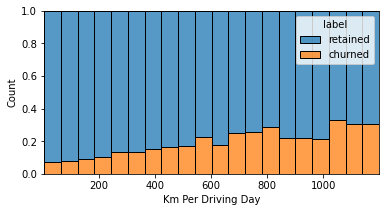

In [ ]:
# Histogram
plt.figure(figsize=(6,3))
sns.histplot(data=df[(df['km_per_driving_day']<=1200)& (df['label']!=0)],x='km_per_driving_day' ,hue='label', multiple='fill',bins=20)
plt.xlabel('Km Per Driving Day')

The churn rate tends to increase as the mean daily distance driven increases, confirming what was found in the previous course. It would be worth investigating further the reasons for long-distance users to discontinue using the app.

#### **Churn rate per number of driving days**

Creating another histogram just like the previous one, only this time it should represent the churn rate for each number of driving days.

Text(0.5, 0, 'Driving Days')

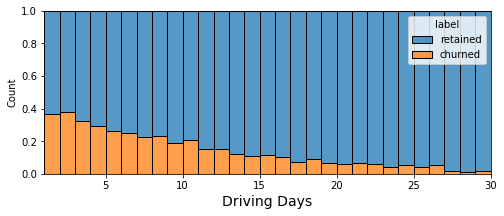

In [ ]:
# Histogram
plt.figure(figsize=(8,3))
sns.histplot(data=df[df['label']!=0], x='driving_days', hue='label',multiple='fill')
plt.xlabel('Driving Days', fontsize=14)

The churn rate is highest for people who didn't use Waze much during the last month. The more times they used the app, the less likely they were to churn. While 40% of the users who didn't use the app at all last month churned, nobody who used the app 30 days churned.

This isn't surprising. If people who used the app a lot churned, it would likely indicate dissatisfaction. When people who don't use the app churn, it might be the result of dissatisfaction in the past, or it might be indicative of a lesser need for a navigational app. Maybe they moved to a city with good public transportation and don't need to drive anymore.

#### **Proportion of sessions that occurred in the last month**

Creating a new column `percent_sessions_in_last_month` that represents the percentage of each user's total sessions that were logged in their last month of use.

In [ ]:
df['percent_sessions_in_last_month'] = df['sessions'] / df['total_sessions'] * 100.0

What is the median value of the new column?

In [ ]:
df['percent_sessions_in_last_month'].median()

42.40878969619262

Now, creating a histogram depicting the distribution of values in this new column.

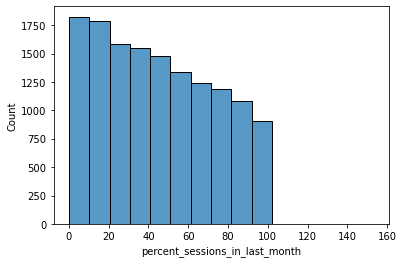

In [ ]:
# Histogram
sns.histplot(df['percent_sessions_in_last_month'],bins=15)

Checking the median value of the `n_days_after_onboarding` variable.

In [ ]:
df['n_days_after_onboarding'].median() / 365

4.4301369863013695

Half of the people in the dataset had 40% or more of their sessions in just the last month, yet the overall median time since onboarding is almost five years.

Making a histogram of `n_days_after_onboarding` for just the people who had 40% or more of their total sessions in the last month.

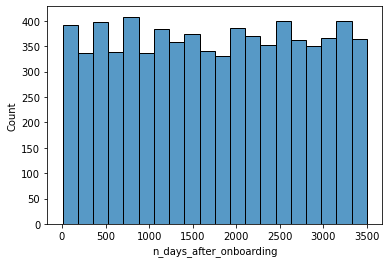

In [ ]:
# Histogram
sns.histplot(data=df[df['percent_sessions_in_last_month']>=40], x='n_days_after_onboarding')

The number of days since onboarding for users with 40% or more of their total sessions occurring in just the last month is a uniform distribution. This is very strange. It's worth asking Waze why so many long-time users suddenly used the app so much in the last month.

### **Part 3b. Handling outliers**

The box plots from the previous section indicated that many of these variables have outliers. These outliers do not seem to be data entry errors; they are present because of the right-skewed distributions.

Depending on what we'll be doing with this data, it may be useful to impute outlying data with more reasonable values. One way of performing this imputation is to set a threshold based on a percentile of the distribution.

To do this we need to write a function that calculates the 95th percentile of a given column, then imputes values > the 95th percentile with the value at the 95th percentile.



In [ ]:
columns = ['sessions','drives','total_sessions','driven_km_drives','duration_minutes_drives']
df[columns].describe()

,sessions,drives,total_sessions,driven_km_drives,duration_minutes_drives
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,75.459564,62.953064,177.611943,3766.606014,1735.200610
std,81.074565,66.318853,140.649351,2623.045867,1473.706786
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,18.000000,16.000000,75.964433,1946.266785,712.059636
50%,51.000000,43.000000,148.433445,3289.425624,1378.459735
75%,106.000000,89.000000,246.098007,5114.144453,2377.960981
max,743.000000,596.000000,1216.154633,21183.401890,15851.727160


Next, applying that function to the following columns:
* `sessions`
* `drives`
* `total_sessions`
* `driven_km_drives`
* `duration_minutes_drives`

In [ ]:
for column in columns:
    P95 = df[column].quantile(0.95)
    df.loc[df[column]>P95,column] = P95

Call ing`describe()` to see if our change worked.

In [ ]:
df[columns].describe()

,sessions,drives,total_sessions,driven_km_drives,duration_minutes_drives
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,76.568705,64.058204,184.031320,3939.632764,1789.647426
std,67.297958,55.306924,118.600463,2216.041510,1222.705167
min,0.000000,0.000000,0.220211,60.441250,18.282082
25%,23.000000,20.000000,90.661156,2212.600607,835.996260
50%,56.000000,48.000000,159.568115,3493.858085,1478.249859
75%,112.000000,93.000000,254.192341,5289.861262,2464.362632
max,243.000000,201.000000,454.363204,8889.794236,4668.899349


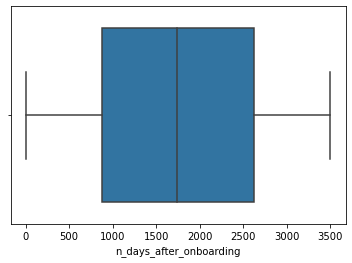

In [ ]:
#sns.histplot(data=df, x='n_days_after_onboarding', bins=20)
sns.boxplot(df['n_days_after_onboarding'])

#### **Conclusion**

Analysis revealed that the overall churn rate is \~17%, and that this rate is consistent between iPhone users and Android users.

The more deeply you explore the data, the more questions arise. In this case, it's worth asking the Waze data team why so many users used the app so much in just the last month.

Also, EDA has revealed that users who drive very long distances on their driving days are _more_ likely to churn, but users who drive more often are _less_ likely to churn. The reason for this discrepancy is an opportunity for further investigation, and it would be something else to ask the Waze data team about.

<img src="images/Execute.png" width="100" height="100" align=left>

## **PACE: Execute**

Consider the questions in your PACE Strategy Document to reflect on the Execute stage.

### **Part 4a. Results and evaluation**

I have learned that this dataset contains 17% of users labeled as `churned`, it also indicates that Iphone users are more than andriod. There is a strong relation between driving days, driving distance and labels.

My other questions are: Why did users did most of their sessions in the last month? Why some driving distance per day are more than 1200km/day?

My client would likely want to know that `driving days` and `activity days` are of c/ourse correlated. And users who drives more distances in less driving days are more likely to churn.


### **Part 4b. Conclusion**

Now that we've explored and visualized your data, the next step is to share our findings.

>
1. Most of variable have righ-skewed distribution which indicates that data contain many outliers. Some of the varibale are uniformly distributed.
2. Some values of distance per days extremly excceds 1200km/day which is logically impossible.
3. Further questions that we would like to explore or ask the Waze team about Why did users did most of their sessions in the last month? Why some driving distance per day are more than 1200km/day?
4. `17.7%` of users churned while `82.3` retained.
5. Most important varibles related to churn rate are: driving days (inversly proportional) and distance per drive (directly proportional).
6. Most users in this dataset used the app for 500-3500 days.